# Modelo autoencoder com fine-tuning

## Implementação do Autoencoder

In [17]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import numpy as np

In [18]:
# Configurações globais
SAMPLE_RATE = 44100
N_FFT = 2048
HOP_LENGTH = 512
SPEC_MAX_LEN = 256  # Número máximo de frames para padronizar os espectrogramas

In [19]:
class Autoencoder(nn.Module):
    def __init__(self):
        super(Autoencoder, self).__init__()
        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, stride=2, padding=1),  # -> (B, 16, 64, 128)
            nn.ReLU(),
            nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1),  # -> (B, 32, 32, 64)
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),  # -> (B, 64, 16, 32)
            nn.ReLU(),
        )
        
        # Calcula o tamanho do tensor após o encoder
        self.flatten_size = 64 * (128 // 8) * (256 // 8)  # 64 * 16 * 32 = 32768
        
        # Latent space
        self.latent = nn.Sequential(
            nn.Flatten(),  # Achata para (B, 32768)
            nn.Linear(self.flatten_size, 256),
            nn.ReLU(),
            nn.Linear(256, 64),
        )
        
        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(64, 256),
            nn.ReLU(),
            nn.Linear(256, self.flatten_size),
            nn.ReLU(),
            nn.Unflatten(1, (64, 16, 32)),  # Desfaz o flatten -> (B, 64, 16, 32)
            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1),  # -> (B, 32, 32, 64)
            nn.ReLU(),
            nn.ConvTranspose2d(32, 16, kernel_size=3, stride=2, padding=1, output_padding=1),  # -> (B, 16, 64, 128)
            nn.ReLU(),
            nn.ConvTranspose2d(16, 1, kernel_size=3, stride=2, padding=1, output_padding=1),  # -> (B, 1, 128, 256)
            nn.Sigmoid(),
        )

    def forward(self, x):
        encoded = self.encoder(x)
        latent = self.latent(encoded)
        decoded = self.decoder(latent)
        return decoded


## Dataset e DataLoader

In [20]:
class SpectrogramDataset(Dataset):
    def __init__(self, spectrograms_path):
        data = np.load(spectrograms_path)
        self.spectrograms = data["spectrograms"]

    def __len__(self):
        return len(self.spectrograms)

    def __getitem__(self, idx):
        spectrogram = self.spectrograms[idx]
        return torch.tensor(spectrogram, dtype=torch.float32).unsqueeze(0)  # Adiciona o canal

In [21]:
# Cria DataLoader
def get_dataloader(path, batch_size=32):
    dataset = SpectrogramDataset(path)
    return DataLoader(dataset, batch_size=batch_size, shuffle=True)

## Treinamento Generalista

In [22]:
def train_autoencoder(model, dataloader, epochs=20, lr=0.001, device="cpu"):
    model.to(device)
    criterion = nn.MSELoss()  # Minimiza a diferença entre espectrograma original e reconstruído
    optimizer = optim.Adam(model.parameters(), lr=lr)

    for epoch in range(epochs):
        model.train()
        total_loss = 0.0

        for batch in dataloader:
            batch = batch.to(device)
            optimizer.zero_grad()

            outputs = model(batch)
            loss = criterion(outputs, batch)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print(f"Epoch {epoch + 1}/{epochs}, Loss: {total_loss / len(dataloader):.6f}")

    return model


## Fine-Tuning

In [23]:
def fine_tune_autoencoder(model, dataloader, epochs=10, lr=0.001, device="cpu"):
    model.to(device)
    
    # Congelar as camadas do encoder
    for param in model.encoder.parameters():
        param.requires_grad = False

    # Apenas o latent space e o decoder serão treinados
    params_to_train = list(model.latent.parameters()) + list(model.decoder.parameters())
    optimizer = optim.Adam(params_to_train, lr=lr)
    criterion = nn.MSELoss()

    for epoch in range(epochs):
        model.train()
        total_loss = 0.0

        for batch in dataloader:
            batch = batch.to(device)
            optimizer.zero_grad()

            outputs = model(batch)
            loss = criterion(outputs, batch)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print(f"Fine-Tuning Epoch {epoch + 1}/{epochs}, Loss: {total_loss / len(dataloader):.6f}")

    return model


## Salvar e Carregar o Modelo

In [24]:
def save_model(model, path):
    torch.save(model.state_dict(), path)

In [25]:
def load_model(model, path, device="cpu"):
    model.load_state_dict(torch.load(path, map_location=device))
    model.to(device)
    return model

In [26]:
# !pip install torch torchvision torchaudio --extra-index-url https://download.pytorch.org/whl/cu117

# Treinamento Generalista
generalist_model = Autoencoder()
train_loader = get_dataloader("../data/IDMT-SMT-GUITAR_V2/dataset1/preprocessed_data/spectrograms_train.npz")
generalist_model = train_autoencoder(generalist_model, train_loader, epochs=500, device="cuda")

# Salvar modelo generalista
save_model(generalist_model, "../models/generalist_autoencoder.pth")

# Fine-Tuning com dados específicos
fine_tune_loader = get_dataloader("../data/IDMT-SMT-GUITAR_V2/dataset1/preprocessed_data/spectrograms_test.npz")
generalist_model = fine_tune_autoencoder(generalist_model, fine_tune_loader, epochs=500, device="cuda")

# Salvar modelo refinado
save_model(generalist_model, "../models/fine_tuned_autoencoder.pth")

Epoch 1/500, Loss: 0.128031
Epoch 2/500, Loss: 0.026953
Epoch 3/500, Loss: 0.022010
Epoch 4/500, Loss: 0.019512
Epoch 5/500, Loss: 0.018608
Epoch 6/500, Loss: 0.018091
Epoch 7/500, Loss: 0.017621
Epoch 8/500, Loss: 0.017126
Epoch 9/500, Loss: 0.016521
Epoch 10/500, Loss: 0.016063
Epoch 11/500, Loss: 0.015747
Epoch 12/500, Loss: 0.015468
Epoch 13/500, Loss: 0.015234
Epoch 14/500, Loss: 0.014966
Epoch 15/500, Loss: 0.014669
Epoch 16/500, Loss: 0.014314
Epoch 17/500, Loss: 0.013899
Epoch 18/500, Loss: 0.013257
Epoch 19/500, Loss: 0.012737
Epoch 20/500, Loss: 0.012316
Epoch 21/500, Loss: 0.011903
Epoch 22/500, Loss: 0.011555
Epoch 23/500, Loss: 0.011267
Epoch 24/500, Loss: 0.010963
Epoch 25/500, Loss: 0.010779
Epoch 26/500, Loss: 0.010620
Epoch 27/500, Loss: 0.010416
Epoch 28/500, Loss: 0.010294
Epoch 29/500, Loss: 0.010239
Epoch 30/500, Loss: 0.010156
Epoch 31/500, Loss: 0.009980
Epoch 32/500, Loss: 0.009869
Epoch 33/500, Loss: 0.009798
Epoch 34/500, Loss: 0.009732
Epoch 35/500, Loss: 0.0

# Avaliar modelo treinado

## Carregar o Modelo Treinado

In [27]:
# Função para carregar o modelo
def load_model(model_class, path, device="cpu"):
    model = model_class()
    model.load_state_dict(torch.load(path, map_location=device))
    model.to(device)
    model.eval()  # Colocar em modo de avaliação
    return model

In [28]:
# Carregar o modelo generalista
generalist_model = load_model(Autoencoder, "../models/generalist_autoencoder.pth", device="cuda")

C:\Users\Andre\AppData\Local\Temp\ipykernel_1792\1177016048.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(path, map_location=device))


## Avaliar no Conjunto de Teste

In [29]:
test_loader = get_dataloader("../data/IDMT-SMT-GUITAR_V2/dataset1/preprocessed_data/spectrograms_test.npz")

In [30]:
# Testar com um batch
with torch.no_grad():
    for batch in test_loader:
        batch = batch.to("cuda")
        output = generalist_model(batch)
        print("Reconstrução:", output.shape)
        break

Reconstrução: torch.Size([32, 1, 128, 256])


## Realizar Fine-Tuning no Instrumento Alvo

In [31]:
fine_tune_loader = get_dataloader("../data/IDMT-SMT-GUITAR_V2/dataset1/preprocessed_data/spectrograms_test.npz")

# Fine-tuning no modelo generalista
fine_tuned_model = fine_tune_autoencoder(generalist_model, fine_tune_loader, epochs=500, device="cuda")

# Salvar o modelo refinado
save_model(fine_tuned_model, "../models/fine_tuned_autoencoder.pth")


Fine-Tuning Epoch 1/500, Loss: 0.004510
Fine-Tuning Epoch 2/500, Loss: 0.003632
Fine-Tuning Epoch 3/500, Loss: 0.003269
Fine-Tuning Epoch 4/500, Loss: 0.002417
Fine-Tuning Epoch 5/500, Loss: 0.002450
Fine-Tuning Epoch 6/500, Loss: 0.002132
Fine-Tuning Epoch 7/500, Loss: 0.001878
Fine-Tuning Epoch 8/500, Loss: 0.001838
Fine-Tuning Epoch 9/500, Loss: 0.001662
Fine-Tuning Epoch 10/500, Loss: 0.001608
Fine-Tuning Epoch 11/500, Loss: 0.001532
Fine-Tuning Epoch 12/500, Loss: 0.001444
Fine-Tuning Epoch 13/500, Loss: 0.001387
Fine-Tuning Epoch 14/500, Loss: 0.001338
Fine-Tuning Epoch 15/500, Loss: 0.001289
Fine-Tuning Epoch 16/500, Loss: 0.001251
Fine-Tuning Epoch 17/500, Loss: 0.001212
Fine-Tuning Epoch 18/500, Loss: 0.001196
Fine-Tuning Epoch 19/500, Loss: 0.001154
Fine-Tuning Epoch 20/500, Loss: 0.001130
Fine-Tuning Epoch 21/500, Loss: 0.001098
Fine-Tuning Epoch 22/500, Loss: 0.001123
Fine-Tuning Epoch 23/500, Loss: 0.001097
Fine-Tuning Epoch 24/500, Loss: 0.001074
Fine-Tuning Epoch 25/500,

## Converter Saída do Modelo para Áudio

In [32]:
import librosa
import librosa.display
import soundfile as sf

# Função para reconstruir áudio
def spectrogram_to_audio(spectrogram, sr=SAMPLE_RATE, hop_length=HOP_LENGTH):
    # Converte dB para potência
    spectrogram = librosa.db_to_power(spectrogram)
    # Reconstrói o sinal de áudio
    audio = librosa.feature.inverse.mel_to_audio(spectrogram, sr=sr, hop_length=hop_length)
    return audio

# Reconstruir áudio de um espectrograma do output
reconstructed_audio = spectrogram_to_audio(output[0, 0].cpu().numpy())

# Salvar o áudio reconstruído
sf.write("../outputs/reconstructed_audio.wav", reconstructed_audio, SAMPLE_RATE)



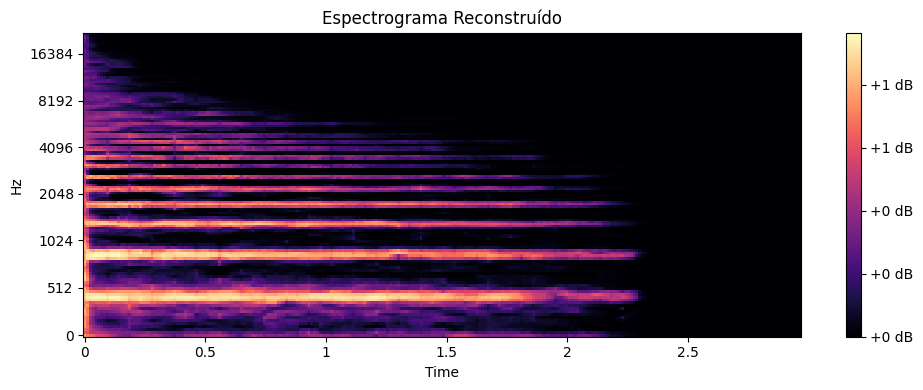

In [33]:
import matplotlib.pyplot as plt

# Visualizar espectrograma de saída
plt.figure(figsize=(10, 4))
librosa.display.specshow(output[0, 0].cpu().numpy(), sr=SAMPLE_RATE, hop_length=HOP_LENGTH, x_axis='time', y_axis='mel')
plt.colorbar(format='%+2.0f dB')
plt.title("Espectrograma Reconstruído")
plt.tight_layout()
plt.show()
